## <font color='blue'>Projeto:</font>
## <font color='blue'>Market Basket Analysis</font>

# O Que é MBA (Market Basket Analysis)?

A Análise de Cesta de Compras (Market Basket Analysis) é uma das principais técnicas usadas por grandes varejistas para descobrir associações entre itens. A técnica funciona procurando combinações de itens que ocorrem juntos com frequência nas transações. Em outras palavras, permite que os varejistas identifiquem as relações entre os itens que as pessoas compram.

A Análise de Cesta de Compras emprega algoritmos de regras de associação, que são amplamente utilizadas para analisar cesta de varejo ou dados de transação e têm o objetivo de identificar regras fortes descobertas em dados de transações comerciais usando medidas de interesse, com base no conceito de regras fortes.

Usaremos uma das técnicas de análise mais úteis para a área de varejo, o **Market Basket Analysis(MBA)ou Análise de Cesta de Compras**

O objetivo deste projeto é identificar associação entre produtos de uma cesta de compras. `Quem compra o Produto A, também compra o Produto B?` `Qual a força dessa relação, se ela existir?` Vamos analisar dados de milhões de transações aplicando Market Basket Analysis.

#### **Market Basket Analysis(MBA)**
 A técnica funciona procurando combinações de itens que ocorrem juntos com frequência nas **`transações`**, `procura descobrir associações entre itens`

#### Banco de Dados Kaggle:

https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis?resource=download

## Instalando e Carregando os Pacotes

In [1]:
# Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## Carregando os Dados

In [2]:
# Carrega os dados

aisle = pd.read_csv('aisles.csv')
department = pd.read_csv('departments.csv')
order = pd.read_csv('orders.csv')
product = pd.read_csv('products.csv')
order_product_prior = pd.read_csv('order_products__prior.csv')
order_product_train = pd.read_csv('order_products__train.csv')

## Análise Exploratória

Não Faz sentido calcular a correlação com colunas do tipo ID

In [3]:
aisle.shape

(134, 2)

In [4]:
aisle.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [5]:
department.shape

(21, 2)

In [6]:
department.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
product.shape

(49688, 4)

In [8]:
product.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [9]:
order.shape

(3421083, 7)

In [10]:
order.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [11]:
order_product_prior.shape

(32434489, 4)

In [12]:
order_product_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [13]:
order_product_train.shape

(1384617, 4)

In [14]:
order_product_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


Verificar o total de registros em todos os datasets de uma vez.

In [15]:
# Total de registros por dataset

dados = np.array([['Aisles', len(aisle)],
                        ['Department', len(department)],
                        ['Product', len(product)],
                        ['Order', len(order)],
                        ['Order_Product_Prior', len(order_product_prior)],
                        ['Order_Product_Train', len(order_product_train)]])

# Convertendo o array para um dataframe (pd.DataFrame)
df = pd.DataFrame(dados, columns = ['Arquivo', 'Total de Registros'])
df

,Arquivo,Total de Registros
0,Aisles,134
1,Department,21
2,Product,49688
3,Order,3421083
4,Order_Product_Prior,32434489
5,Order_Product_Train,1384617


In [16]:
# Total de itens nas categorias de eval_set

order['eval_set'].value_counts(dropna=False)

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

## Limpeza dos Dados

### Verificando Valores Ausentes

**OBS:** O dataset ja está bastante organizado e limpo!!

In [17]:
aisle.isna().sum()

aisle_id    0
aisle       0
dtype: int64

In [18]:
department.isna().sum()

department_id    0
department       0
dtype: int64

In [19]:
order.isna().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

days_since_prior_order = Numero de dias desde o pedido anterior:

Se o usuario estiver fazendo o primeiro pedido não haverá pedido anterior. Não é algo errado, porem esta faltando registro e precisa ser tratado

In [20]:
product.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [21]:
order_product_prior.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [22]:
order_product_train.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

### Feature Extraction/ Extração de Atributos

### Merge da Tabela order_product_prior com order, product, aisle e department

In [ ]:
# Merge

# order_product_prior com order
order_product_prior = order_product_prior.merge(order, on = 'order_id', how = 'left')

# order_product_prior com product
order_product_prior = order_product_prior.merge(product, on = 'product_id', how = 'left')

# order_product_prior com aisle
order_product_prior = order_product_prior.merge(aisle, on = 'aisle_id', how = 'left')

# order_product_prior com department
order_product_prior = order_product_prior.merge(department, on = 'department_id', how = 'left')

OBS: Não faz sentido analisar as tabelas separadas por isso foi feito o merge

In [26]:
order_product_prior.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [27]:
order_product_prior.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [28]:
# Proporção de valores nulos

order_product_prior.isnull().sum() / len(order_product_prior) * 100

order_id                  0.00000
product_id                0.00000
add_to_cart_order         0.00000
reordered                 0.00000
user_id                   0.00000
eval_set                  0.00000
order_number              0.00000
order_dow                 0.00000
order_hour_of_day         0.00000
days_since_prior_order    6.40697
product_name              0.00000
aisle_id                  0.00000
department_id             0.00000
aisle                     0.00000
department                0.00000
dtype: float64

Vamos manter a variável days_since_prior_order por duas razões:

1- O percentual de valores ausentes é apenas de 6.4%.

2- Não usaremos a variável com o algoritmo MBA.

### Merge da Tabela order_product_train com order, product, aisle e department

In [29]:
%%time
order_product_train = order_product_train.merge(order, on = 'order_id', how = 'left')
order_product_train = order_product_train.merge(product, on = 'product_id', how = 'left')
order_product_train = order_product_train.merge(aisle, on = 'aisle_id', how = 'left')
order_product_train = order_product_train.merge(department, on = 'department_id', how = 'left')

CPU times: total: 1.41 s
Wall time: 2.29 s


In [30]:
order_product_train.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods
5,1,13176,6,0,112108,train,4,4,10,9.0,Bag of Organic Bananas,24,4,fresh fruits,produce
6,1,47209,7,0,112108,train,4,4,10,9.0,Organic Hass Avocado,24,4,fresh fruits,produce
7,1,22035,8,1,112108,train,4,4,10,9.0,Organic Whole String Cheese,21,16,packaged cheese,dairy eggs
8,36,39612,1,0,79431,train,23,6,18,30.0,Grated Pecorino Romano Cheese,2,16,specialty cheeses,dairy eggs
9,36,19660,2,1,79431,train,23,6,18,30.0,Spring Water,115,7,water seltzer sparkling water,beverages


In [31]:
order_product_train.isna().sum()

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64

> Vamos agrupar os dados para aplicar o algoritmo Apriori e preparar o dataset com todas as transações.

In [32]:
%%time
order_agrupada = pd.DataFrame(order_product_prior.groupby('order_id')['product_id'].count().reset_index())

CPU times: total: 1.16 s
Wall time: 1.23 s


In [34]:
order_agrupada.shape

(3214874, 2)

In [37]:
order_agrupada.head()

,order_id,product_id
0,2,9
1,3,8
2,4,13
3,5,26
4,6,3


✔️ Lista de produtos por pedido

In [38]:
transacoes = (order_product_prior.groupby('order_id')['product_id'].apply(list).reset_index())

In [39]:
transacoes.head()

,order_id,product_id
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132..."
4,6,"[40462, 15873, 41897]"


#### Os dados estão prontos para o apriori!!

## Análise Estatística Descritiva

### 1- Qual o Número de Pedidos Mais Frequente Entre os Usuários?

In [40]:
order.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [41]:
# Agrupa os dados por usuário e número do pedido, agregando pelo maior valor

ord_max_count = (order.groupby("user_id")['order_number'].max().reset_index())
ord_max_count.head()

,user_id,order_number
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [42]:
# Faz a contagem por número de pedidos

ord_max_count = ord_max_count.order_number.value_counts()

ord_max_count.head()

order_number
4    23986
5    19590
6    16165
7    13850
8    11700
Name: count, dtype: int64

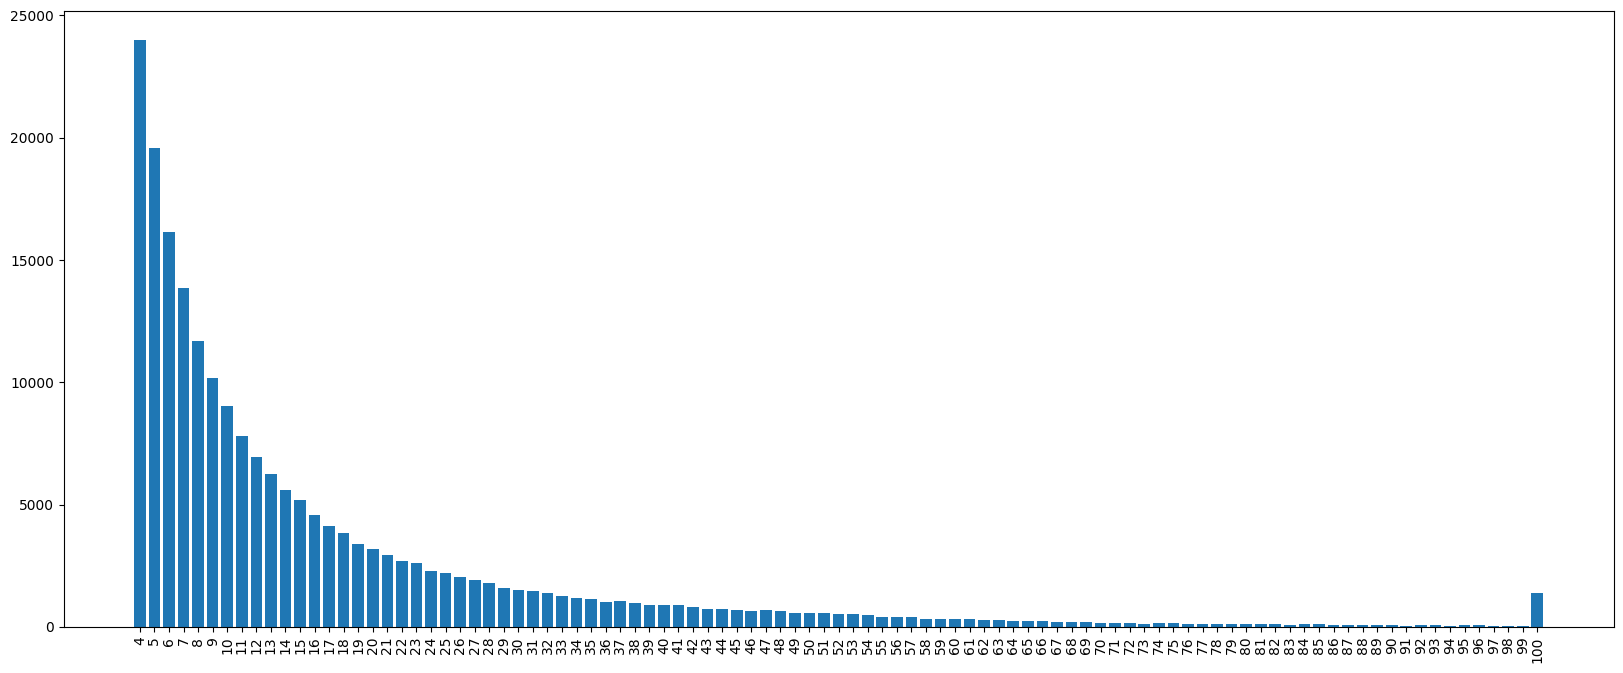

In [43]:
# Plot

plt.figure(figsize = (20,8))

plt.bar(ord_max_count.index, ord_max_count.values)

plt.xticks(ord_max_count.index, rotation = 'vertical')

plt.show()

### 2- Qual Dia da Semana Tem o Maior Número de Pedidos?

**Frequências de pedidos por dia da semana (dow = day of the week)**

In [44]:
# Frequências de pedidos por dia da semana (dow = day of the week)

freq_dow = order.groupby('order_dow').size() # size() = count(), porem ele conta os NaN

x = freq_dow.index #Dias
y = freq_dow.values #Frequencia

In [45]:
freq_dow

order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
dtype: int64

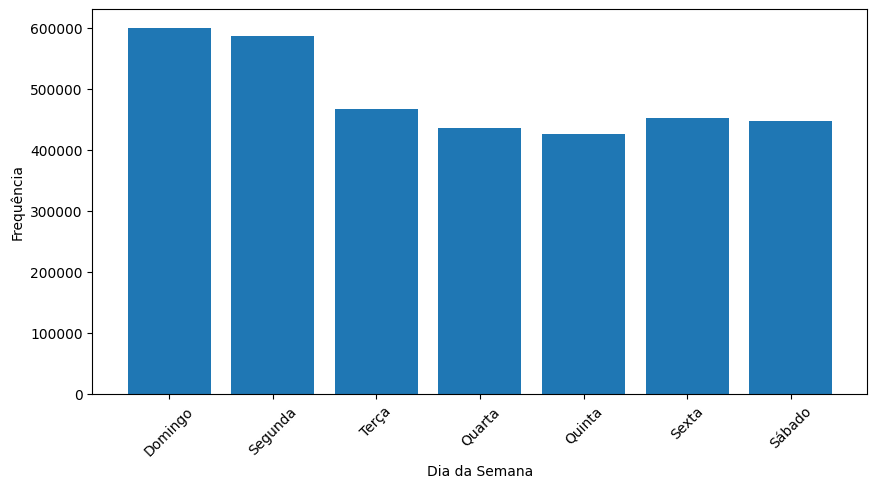

In [46]:
# Plot

plt.figure(figsize = (10,5))

plt.bar(x,y) # pode usar o color = 'cor' para dar cor ao grafico

plt.xlabel('Dia da Semana')
plt.ylabel('Frequência')

plt.xticks(x,['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado'], rotation =45)

plt.show()

Resultado: Domingo e Segunda são os dias com maior numero de pedidios(frequência)

### 3- Qual Hora do Dia Tem o Maior Número de Pedidos?

In [47]:
# Frequências de pedidos pela hora do dia
freq_hour = order.groupby('order_hour_of_day').size()

x = freq_hour.index
y = freq_hour.values

In [48]:
freq_hour

order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
dtype: int64

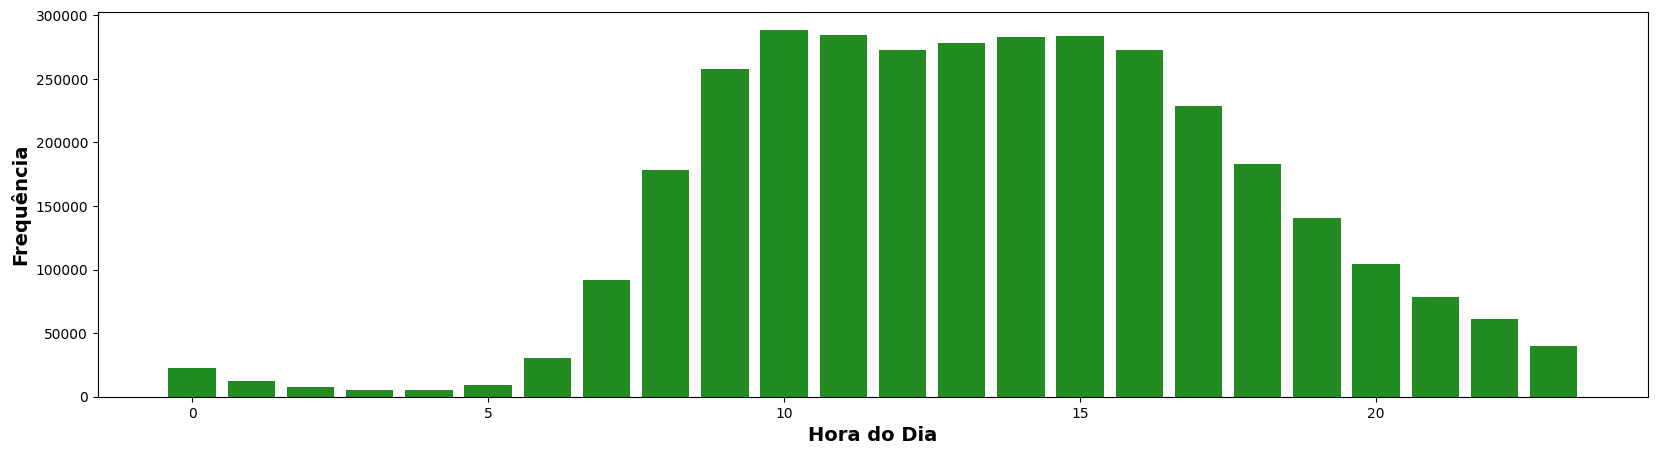

In [53]:
# Plot
plt.figure(figsize = (20,5))
plt.bar(x,y,color = 'forestgreen')

plt.xlabel('Hora do Dia', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

Resultado: Das 9h até as 17h tem maior numero de pedidos

### 4- Qual Departamento Tem o Maior Número de Pedidos?

In [55]:
# Contagem de pedidos por departamento

dept_cnt = order_product_prior['department'].value_counts()
dept_cnt

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
breakfast           709569
meat seafood        708931
personal care       447123
babies              423802
international       269253
alcohol             153696
pets                 97724
missing              69145
other                36291
bulk                 34573
Name: count, dtype: int64

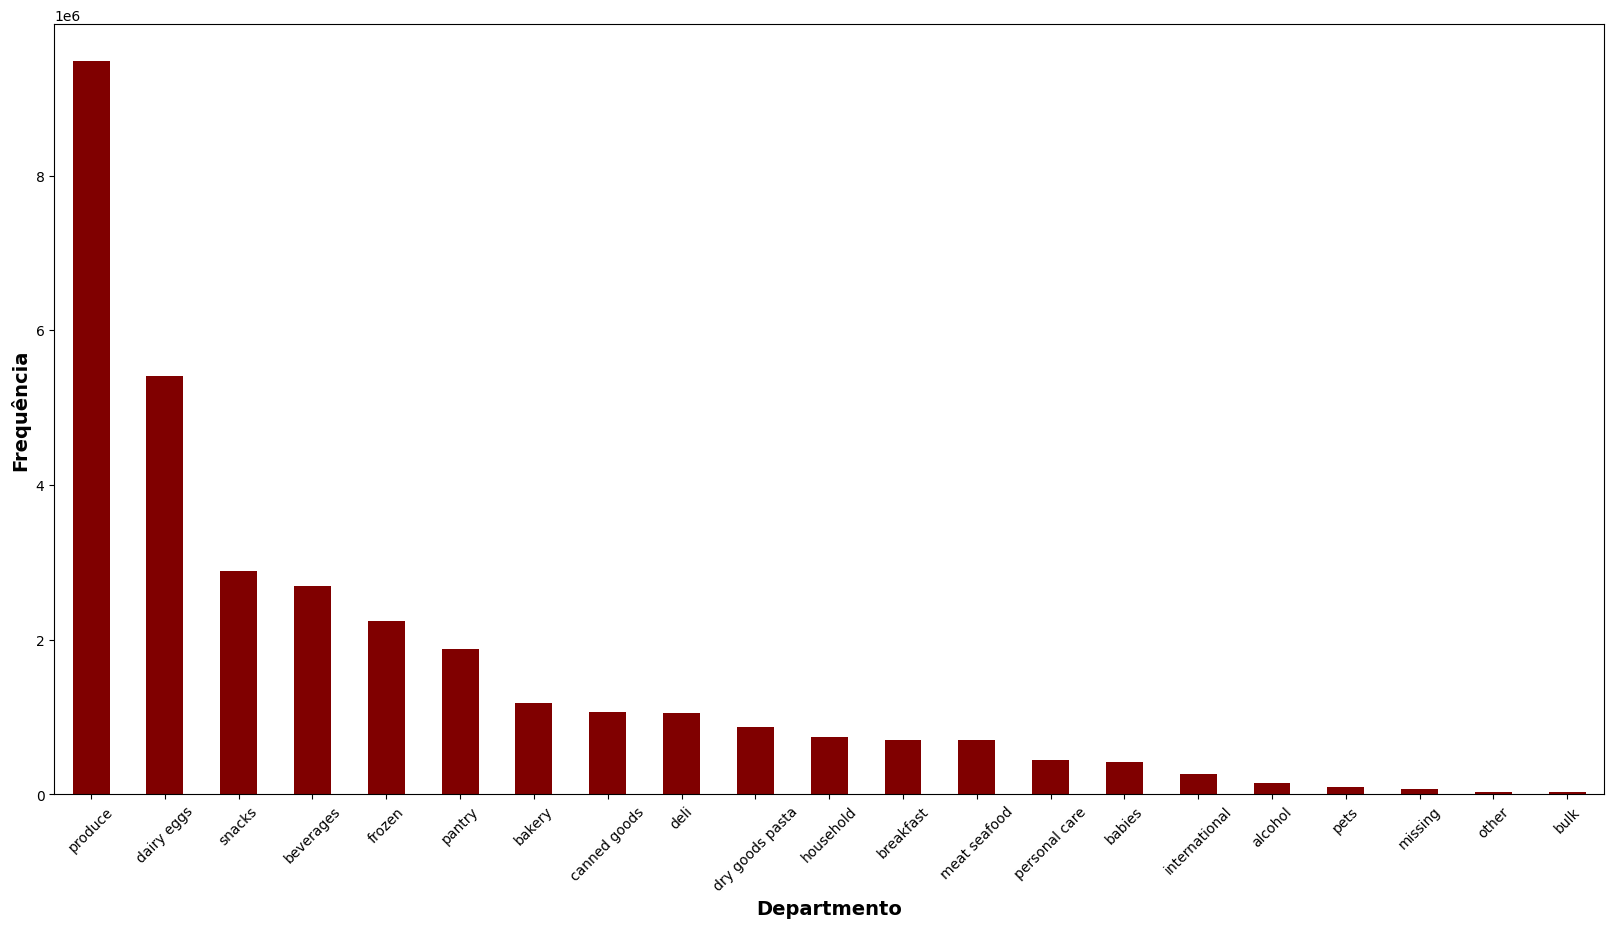

In [56]:
# Plot

fig = plt.figure(figsize = (20,10))
dept_cnt.plot(kind = "bar", color = 'maroon')

plt.xticks(rotation = 45) # 45 graus

plt.xlabel('Departmento', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')

plt.show()

### 5- Quais os 20 Principais Corredores Por Frequência de Pedidos?

In [59]:
# Os 20 principais corredores e sua frequência de pedidos
aisle_cnt = order_product_prior['aisle'].value_counts()
aisle_cnt.head(20)

aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
refrigerated                      575881
frozen produce                    522654
ice cream ice                     498425
crackers                          458838
energy granola bars               456386
eggs                              452134
lunch meat                        395130
frozen meals                      390299
baby food formula                 382456
fresh herbs                       377741
Name: count, dtype: int64

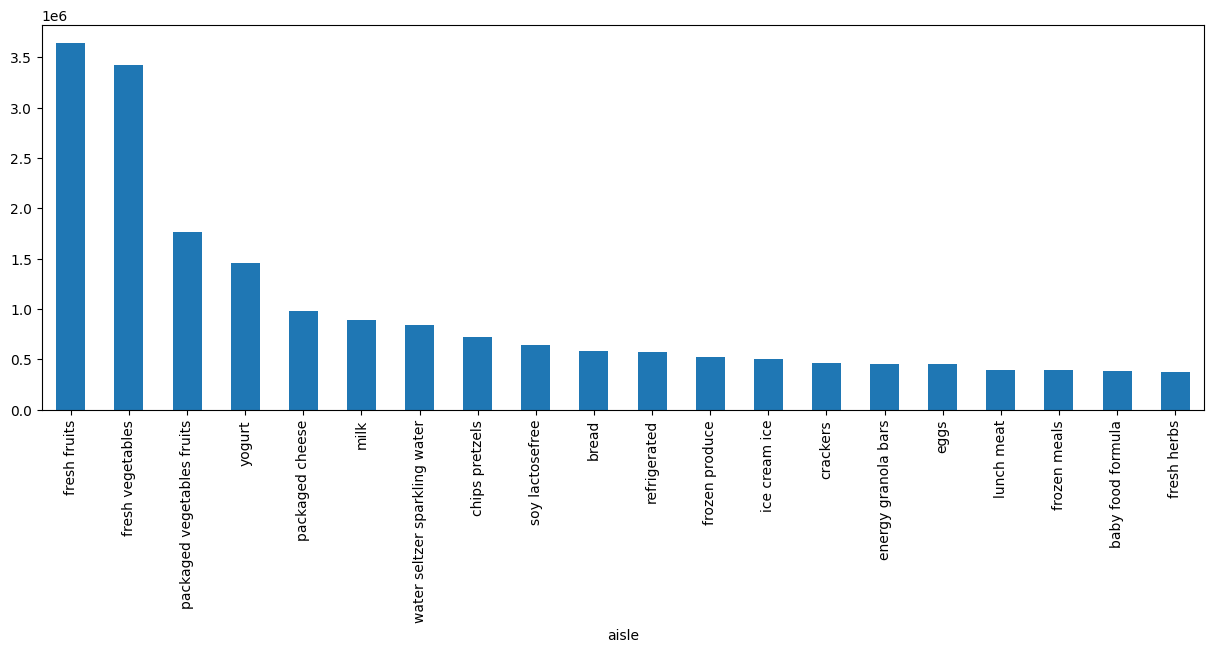

In [60]:
# Plot

aisle_cnt = order_product_prior['aisle'].value_counts().head(20).plot(kind='bar', figsize=(15,5), rot=90)

### 6- Quais os 20 Principais Produtos Por Frequência de Pedidos?

In [61]:
# Os 20 principais produtos por frequência de pedido

prod_cnt = order_product_prior['product_name'].value_counts().head(20)
prod_cnt

product_name
Banana                      472565
Bag of Organic Bananas      379450
Organic Strawberries        264683
Organic Baby Spinach        241921
Organic Hass Avocado        213584
Organic Avocado             176815
Large Lemon                 152657
Strawberries                142951
Limes                       140627
Organic Whole Milk          137905
Organic Raspberries         137057
Organic Yellow Onion        113426
Organic Garlic              109778
Organic Zucchini            104823
Organic Blueberries         100060
Cucumber Kirby               97315
Organic Fuji Apple           89632
Organic Lemon                87746
Apple Honeycrisp Organic     85020
Organic Grape Tomatoes       84255
Name: count, dtype: int64

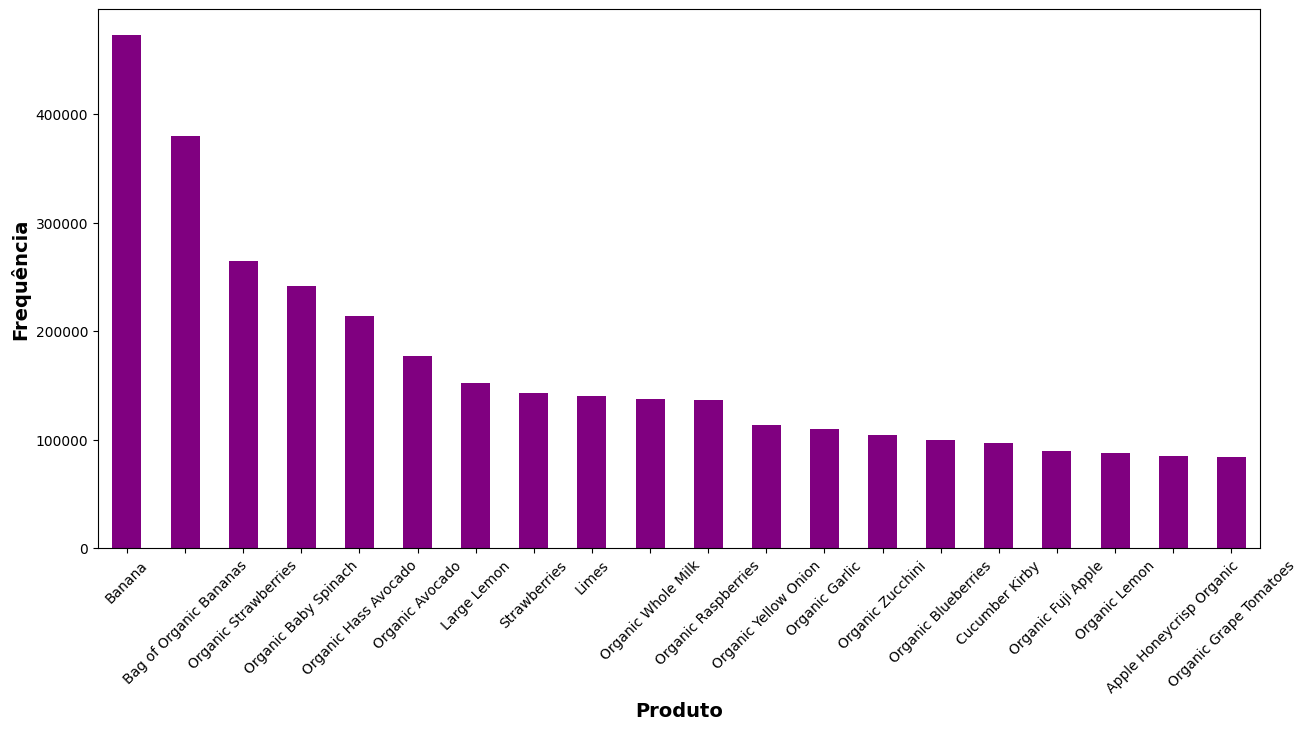

In [63]:
# Plot

fig = plt.figure(figsize = (15,7))
prod_cnt.plot(kind = "bar", color = 'purple')

plt.xticks(rotation = 45)

plt.xlabel('Produto', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')

plt.show()

### 7- Análise de Novos Pedidos Semelhantes a Pedidos Anteriores (reorder/Recompra)

In [68]:
%%time
temp_df = order_product_prior.groupby("product_name")["reordered"].agg(['count', 'sum']).sort_values('count', ascending = False).reset_index()

CPU times: total: 5.28 s
Wall time: 5.38 s


In [67]:
temp_df.rename(columns = {'count':'total','sum':'reorders'}).head(10)

,product_name,total,reorders
0,Banana,472565,398609
1,Bag of Organic Bananas,379450,315913
2,Organic Strawberries,264683,205845
3,Organic Baby Spinach,241921,186884
4,Organic Hass Avocado,213584,170131
5,Organic Avocado,176815,134044
6,Large Lemon,152657,106255
7,Strawberries,142951,99802
8,Limes,140627,95768
9,Organic Whole Milk,137905,114510


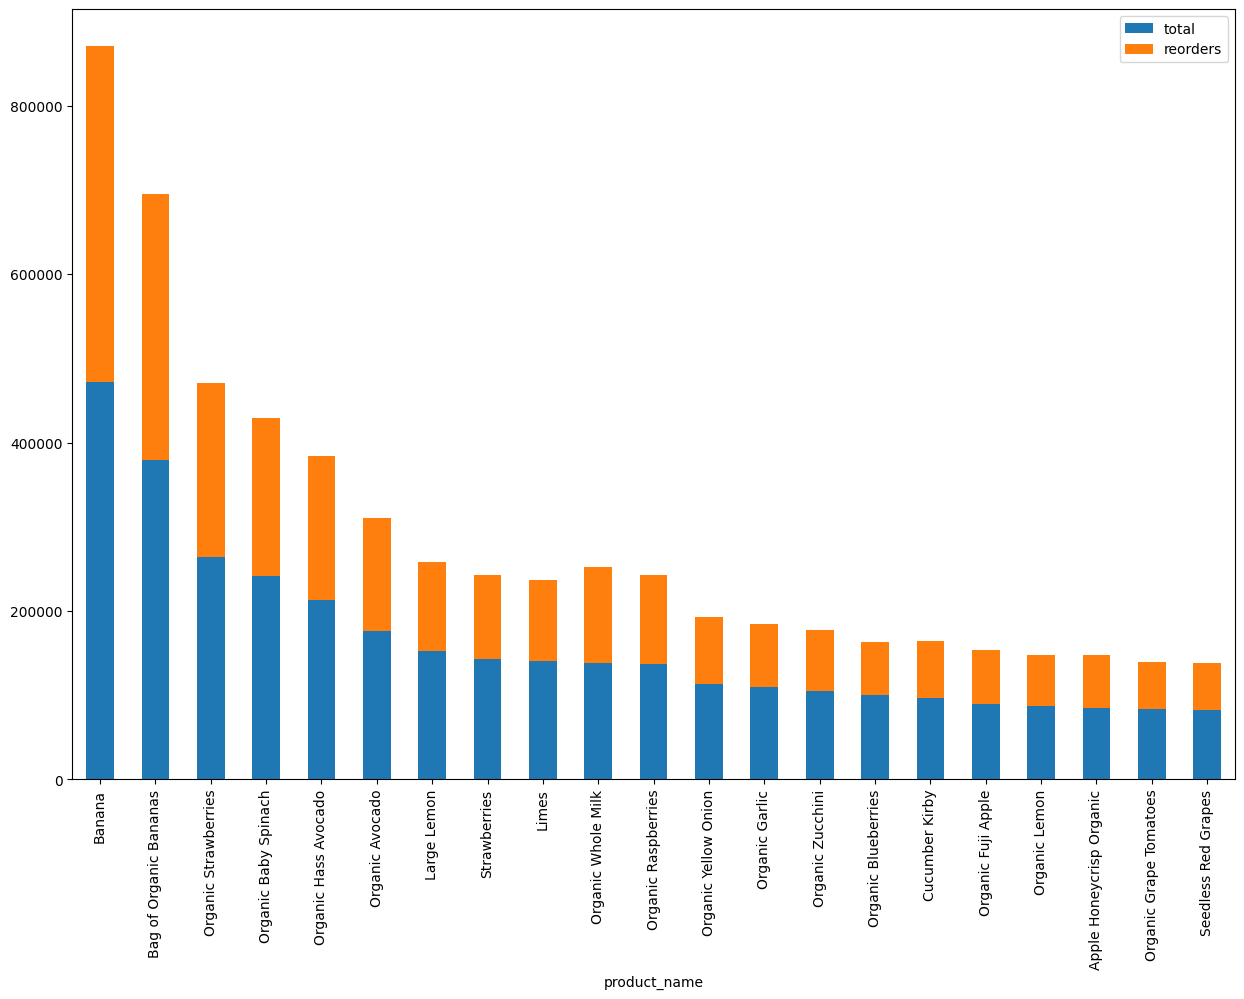

In [69]:
# Plot  

temp_df = order_product_prior.groupby("product_name")["reordered"].agg(['count', 'sum']).sort_values('count', ascending = False).rename(columns = {'count':'total','sum':'reorders'}).reset_index().head(21).plot(kind='bar', x='product_name', figsize=(15,10), stacked=True, rot=90)

### 7- Análise de Reorder Por Departamento ao Longo do Tempo

In [70]:
# Agrupando os dados por departamento e reorder

agruped_df = order_product_prior.groupby('department')['reordered'].agg('mean').reset_index() #pode fazer com ou sem agg()
agruped_df.head()

,department,reordered
0,alcohol,0.569924
1,babies,0.578971
2,bakery,0.628141
3,beverages,0.653460
4,breakfast,0.560922


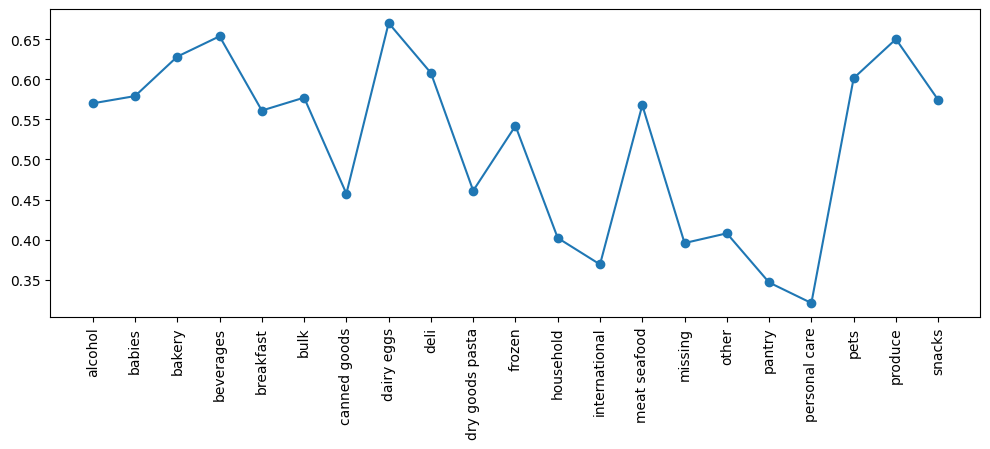

In [71]:
# Plot

plt.figure(figsize=(12,4))

x = agruped_df['department']
y = agruped_df['reordered']

plt.plot(x, y, marker='o')

plt.xticks(rotation=90)

plt.show()

### 8- Análise de Reorder e Pedidos

**Relação entre recompra/Reorder(sum) e pedidos que não foram recomprados not_reordered**

In [72]:
%%time
temp_df = order_product_prior.groupby("department")["reordered"].agg(['count', 'sum']).sort_values('count', ascending = False).reset_index()

CPU times: total: 2.27 s
Wall time: 2.25 s


In [73]:
temp_df.head()

,department,count,sum
0,produce,9479291,6160710
1,dairy eggs,5414016,3627221
2,snacks,2887550,1657973
3,beverages,2690129,1757892
4,frozen,2236432,1211890


In [74]:
temp_df['not_reordered'] = temp_df['count'] - temp_df['sum']

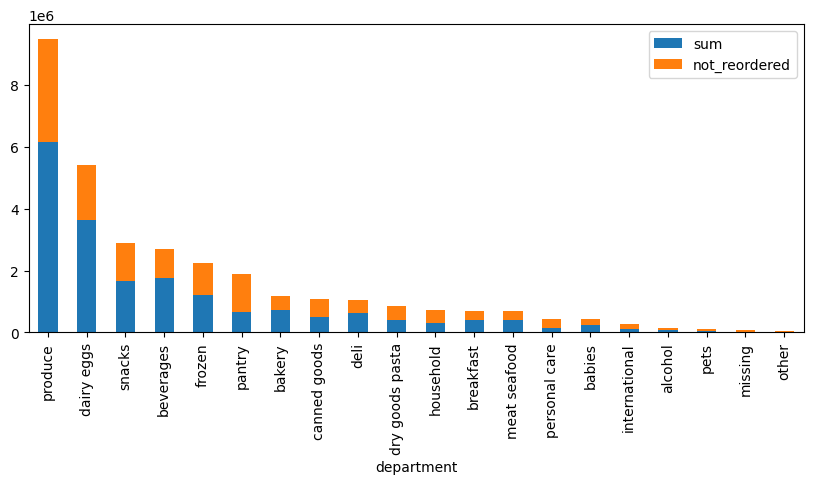

In [77]:
temp_df_plot = temp_df.head(20).set_index('department')

temp_df_plot[['sum', 'not_reordered']].plot(kind='bar',stacked=True,figsize=(10,4))

plt.xticks(rotation=90)

plt.show()

In [79]:
temp_df_plot.head(10)

,count,sum,not_reordered
department,,,
produce,9479291,6160710,3318581
dairy eggs,5414016,3627221,1786795
snacks,2887550,1657973,1229577
beverages,2690129,1757892,932237
frozen,2236432,1211890,1024542
pantry,1875577,650301,1225276
bakery,1176787,739188,437599
canned goods,1068058,488535,579523
deli,1051249,638864,412385


### 9- Análise de Reorder Por Corredor **média**

In [80]:
grouped_df = order_product_prior.groupby(["aisle"])["reordered"].agg("mean").reset_index()

grouped_df.head()

,aisle,reordered
0,air fresheners candles,0.309052
1,asian foods,0.351132
2,baby accessories,0.550980
3,baby bath body care,0.295770
4,baby food formula,0.590259


In [84]:
list(grouped_df['aisle'])[0:20]

['air fresheners candles',
 'asian foods',
 'baby accessories',
 'baby bath body care',
 'baby food formula',
 'bakery desserts',
 'baking ingredients',
 'baking supplies decor',
 'beauty',
 'beers coolers',
 'body lotions soap',
 'bread',
 'breakfast bakery',
 'breakfast bars pastries',
 'bulk dried fruits vegetables',
 'bulk grains rice dried goods',
 'buns rolls',
 'butter',
 'candy chocolate',
 'canned fruit applesauce']

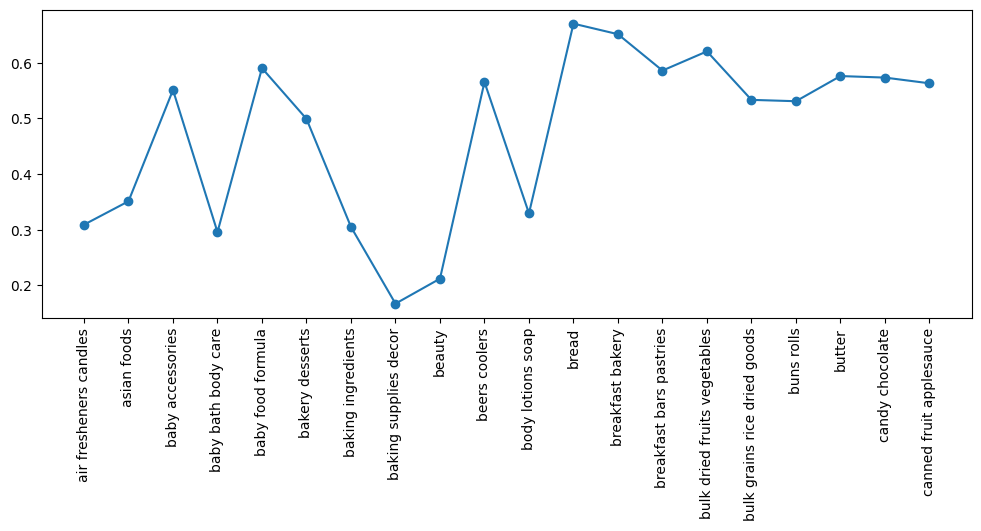

In [85]:
# Corredor x Taxa de Reorder

plt.figure(figsize=(12,4))

x = grouped_df['aisle'].head(20)
y = grouped_df['reordered'].head(20)

plt.plot(x, y, marker='o')

plt.xticks(rotation=90)

plt.show()

**Resultado:** Total de Recompra(reorder) por corredor de produto

O corredor "baking suppliers decor" recebeu menos novos pedidios

O corredor bread tem uma quantidade grande de novos pedidos

### 10- Análise de Reorder Por Corredor (Total)

In [86]:
%%time
temp_df = order_product_prior.groupby("aisle")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'}).sort_values('total', ascending = False).reset_index()


CPU times: total: 2.66 s
Wall time: 2.68 s


In [87]:
temp_df.head()

,aisle,total,reorders
0,fresh fruits,3642188,2615469
1,fresh vegetables,3418021,2032172
2,packaged vegetables fruits,1765313,1127177
3,yogurt,1452343,997018
4,packaged cheese,979763,573383


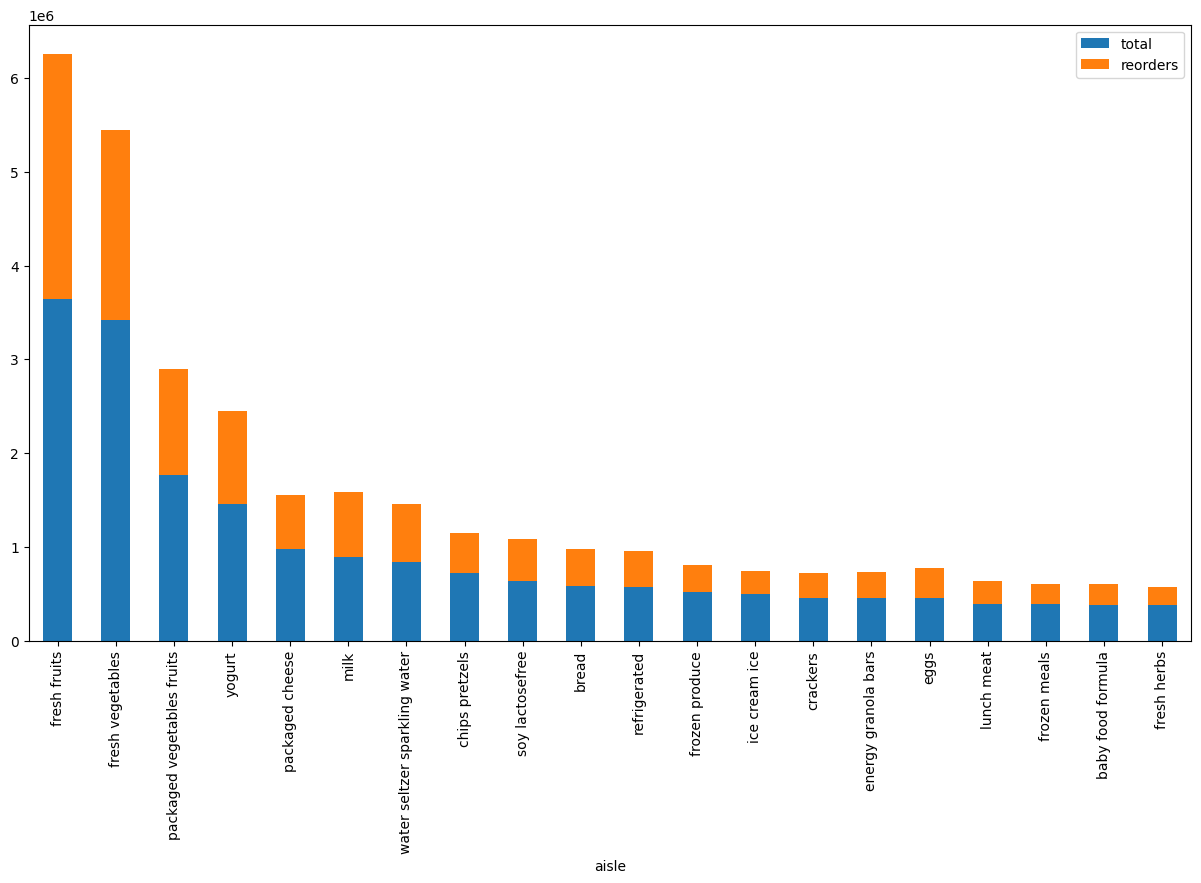

In [88]:
# Plot

temp_df = order_product_prior.groupby("aisle")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'}).sort_values('total', ascending = False).reset_index().head(20).plot(kind='bar', x='aisle', figsize=(15,8), stacked=True, rot=90)

> Vamos verificar a relação entre como a ordem de adição do produto ao carrinho afeta a proporção de novos pedidos

In [93]:
order_product_prior["add_to_cart_order_mod"] = order_product_prior["add_to_cart_order"]

order_product_prior.loc[order_product_prior["add_to_cart_order_mod"] > 70, "add_to_cart_order_mod"] = 70

grouped_df = order_product_prior.groupby("add_to_cart_order_mod")["reordered"].mean().reset_index()

In [94]:
grouped_df.head(10)

,add_to_cart_order_mod,reordered
0,1,0.677533
1,2,0.676251
2,3,0.658037
3,4,0.636958
4,5,0.617383
5,6,0.600420
6,7,0.585687
7,8,0.573247
8,9,0.561474
9,10,0.551018


## Implementação do Algoritmo Apriori

Métricas:

![title](imagens/regras.png)

Support = Fração de transações que contêm A e B.

![title](imagens/support.png)

Confidence = A frequência com que B aparece em transações que contêm apenas A.

![title](imagens/confidence.png)

Lift = Quanto aumentou nossa confiança de que B será comprado, dado que A foi comprado.

![title](imagens/lift.png)

In [ ]:
# Imports

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [ ]:
# Extrair a lista de proditos

transacoes_lista = transacoes['product_id'].tolist()

In [ ]:
# One-Hot Encoding

te = TransactionEncoder()

te_array = te.fit(transacoes_lista).transform(transacoes_lista)

df_mba = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
# Encontrar combinações de produtos que aparecem com frequência nas transações.

frequent_itemsets = apriori(df_mba, min_support=0.01, use_colnames=True)

In [ ]:
# Gerar regras de associação | transforma combinações de produtos em regras de compra.
# Produtos que aparecem juntos com frequência.

rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.3)

In [ ]:
# Ordenar pelas melhores regras

rules = rules.sort_values(by='lift', ascending=False)

rules.head(10)

# 📊 Interpretação de negócio

Exemplo:

{33120} → {28985}

    support = 0.05
    confidence = 0.41
    lift = 1.7

**Significa:**

>5% das compras possuem os dois produtos
>
>quem compra 33120 tem 41% de chance de comprar 28985

In [ ]:
# 📈 Análise adicional

# Top produtos:

transacoes.explode('product_id')['product_id'].value_counts().head(10)

In [ ]:
# DataFrame de Itemsets Frequentes

frequent_itemsets = apriori(df_mba, min_support=0.01, use_colnames=True)

In [ ]:
# Top combinações mais frequentes

top_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

top_itemsets

In [ ]:
# Gráfico — Top Itemsets Frequentes 📊

top_itemsets.set_index('itemsets')['support'].plot(kind='bar')

plt.title("Top Itemsets Frequentes")
plt.ylabel("Support")
plt.xlabel("Itemsets")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Top 10 regras mais fortes

top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

top_rules

# Essas são as associações mais fortes entre produtos.

## Conclusão

Aplicando Matemática e Estatística via programação executamos uma análise de MBA gerando como resultado as regras de associação entre os produtos com diferentes métricas.

# Fim